# Leiter 투구 키네마틱 분석
볼넷 vs 삼진 포즈 비교

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 한글 폰트
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('.').resolve()
sys.path.insert(0, str(BASE))

WALK_DIR = BASE / 'pose_output/leiter'
SO_DIR   = BASE / 'pose_output/leiter_so'

print('BASE:', BASE)

BASE: /Users/jisoyun/Desktop/Final_Baseball/Notebooks/지소윤/baseball_kinematics


## 1. 데이터 로드

In [4]:
from pose_preprocessor import preprocess_pose, XY_COLS
from release_detector import detect_release, extract_window
from run_analysis import calc_kinematics, THROW_HAND

def load_proc_csvs(directory):
    """전처리된 _proc.csv 전체 로드 → {play_id: df} 딕셔너리"""
    files = sorted(Path(directory).glob('*_trimmed_yolo_pose_proc.csv'))
    data = {}
    for f in files:
        play_id = f.stem.replace('_trimmed_yolo_pose_proc', '')
        data[play_id] = pd.read_csv(f)
    print(f'{directory.name}: {len(data)}개 로드')
    return data

walk_data = load_proc_csvs(WALK_DIR)
so_data   = load_proc_csvs(SO_DIR)

leiter: 28개 로드
leiter_so: 18개 로드


In [5]:
# 요약 CSV 로드
walk_summary = pd.read_csv(WALK_DIR / 'leiter_walks_analysis.csv')
so_summary   = pd.read_csv(SO_DIR   / 'leiter_so_analysis.csv')

walk_summary['label'] = '볼넷'
so_summary['label']   = '삼진'

# 이상치 제거: 팔꿈치가 릴리즈 윈도우 내내 >160° = 카메라 방향 foreshortening
# (팔이 카메라 쪽으로 뻗을 때 2D 투영에서 어깨-팔꿈치-손목이 일직선으로 보임)
def filter_outliers(df, label):
    bad = (
        (df['elbow_angle_min'].fillna(0) > 150)  # 창 내 최소 팔꿈치각도도 150° 이상 = foreshortening
        | df['elbow_angle_mean'].isna()          # 팔꿈치 데이터 없음
    )
    removed = df[bad][['play_id','elbow_angle_mean','elbow_angle_min','arm_flyout_rate']]
    if len(removed):
        print(f'[{label}] 제외 {len(removed)}개:')
        print(removed.to_string(index=False))
    return df[~bad].copy()

walk_summary = filter_outliers(walk_summary, '볼넷')
so_summary   = filter_outliers(so_summary,   '삼진')

print(f'볼넷: {len(walk_summary)}개 | 삼진: {len(so_summary)}개')
walk_summary.head(3)


[볼넷] 제외 1개:
                             play_id  elbow_angle_mean  elbow_angle_min  arm_flyout_rate
e387cabe-12a1-394e-9d16-22240aeece46             169.3            154.3            0.929
[삼진] 제외 2개:
                             play_id  elbow_angle_mean  elbow_angle_min  arm_flyout_rate
2d91eec4-8ca9-3aad-b07f-1de5475e5839            177.23           175.07              1.0
ae464439-60ac-3047-8ee0-fe292b5885e1               NaN              NaN              NaN
볼넷: 24개 | 삼진: 9개


,play_id,n_frames,shoulder_angle_mean,shoulder_angle_max,shoulder_angle_min,shoulder_angle_std,hip_angle_mean,hip_angle_max,hip_angle_min,hip_angle_std,...,seq_hip_to_trunk,seq_trunk_to_elbow,seq_elbow_to_wrist,game_date,pitch_name,release_speed,event,balls,strikes,label
0,028354e1-5cfc-3b08-a40a-38ca8efa32e1,36,-236.95,-162.49,-398.09,83.98,116.14,164.47,-24.17,70.49,...,22.0,-2.0,2.0,2025-09-09,4-Seam Fastball,96.8,walk,3.0,2.0,볼넷
1,04922a93-2197-3389-86de-fa070dbe45aa,36,260.35,361.15,126.46,94.03,263.09,361.21,125.68,94.71,...,1.0,-4.0,-5.0,2025-08-06,4-Seam Fastball,97.4,walk,3.0,2.0,볼넷
2,095c4a43-d2bf-3b3d-82dd-18e420d2b80e,36,-216.38,-176.53,-391.93,66.46,199.53,373.35,151.72,73.44,...,10.0,11.0,-1.0,2025-08-18,4-Seam Fastball,96.3,walk,3.0,2.0,볼넷


## 2. 릴리즈 윈도우 각도 시계열
릴리즈 포인트(빨간 점선) 전후 각도 변화 확인

In [6]:
def plot_angle_series(play_id, df, label, color, ax_array):
    rel_frame, rel_time = detect_release(df, throw_hand=THROW_HAND, method='velocity')
    if rel_frame is None:
        print(f'  {play_id[:8]}: 릴리즈 감지 실패')
        return

    df_win = extract_window(df, rel_frame, pre=25, post=15)
    kin    = calc_kinematics(df_win, throw_hand=THROW_HAND)
    if kin.empty:
        return

    kin['rel_frame'] = kin['frame'] - rel_frame

    pairs = [
        ('elbow_angle',    '팔꿈치 각도'),
        ('knee_angle',     '앞발 무릎 각도'),
        ('shoulder_angle', '어깨 기울기'),
        ('hip_angle',      '골반 기울기'),
    ]

    for ax, (col, title) in zip(ax_array, pairs):
        s = kin[['rel_frame', col]].dropna()
        ax.plot(s['rel_frame'], s[col], color=color, lw=2, alpha=0.8,
                label=f'{label} {play_id[:8]}')
        ax.axvline(0, color='red', lw=1.2, linestyle='--')
        ax.set_title(title)
        ax.set_xlabel('릴리즈 기준 프레임')
        ax.set_ylabel('각도 (°)')
        ax.grid(True, alpha=0.3)

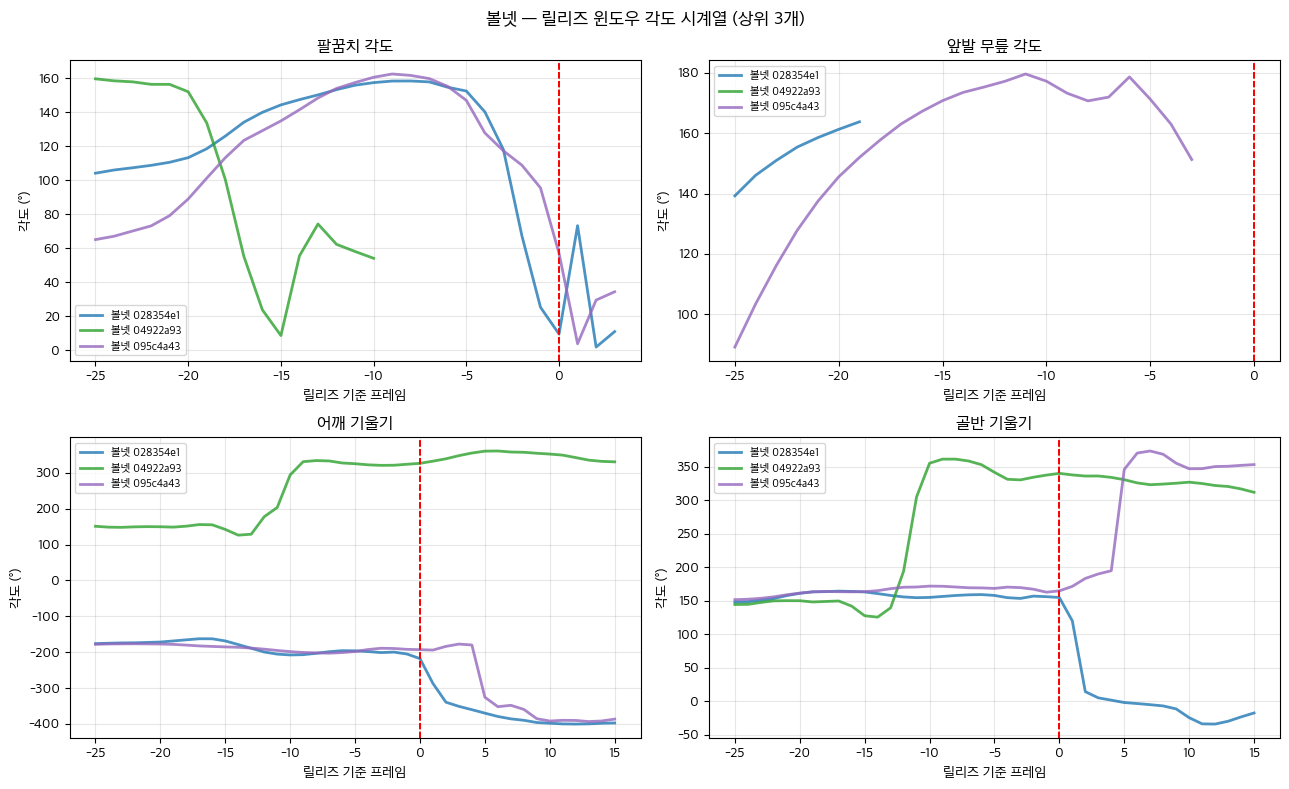

In [7]:
# 볼넷 3개 오버레이
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('볼넷 — 릴리즈 윈도우 각도 시계열 (상위 3개)', fontsize=13)

colors = ['#1f77b4', '#2ca02c', '#9467bd']
sample_walks = list(walk_data.items())[:3]

for (pid, df), col in zip(sample_walks, colors):
    plot_angle_series(pid, df, '볼넷', col, axes.flatten())

for ax in axes.flatten():
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

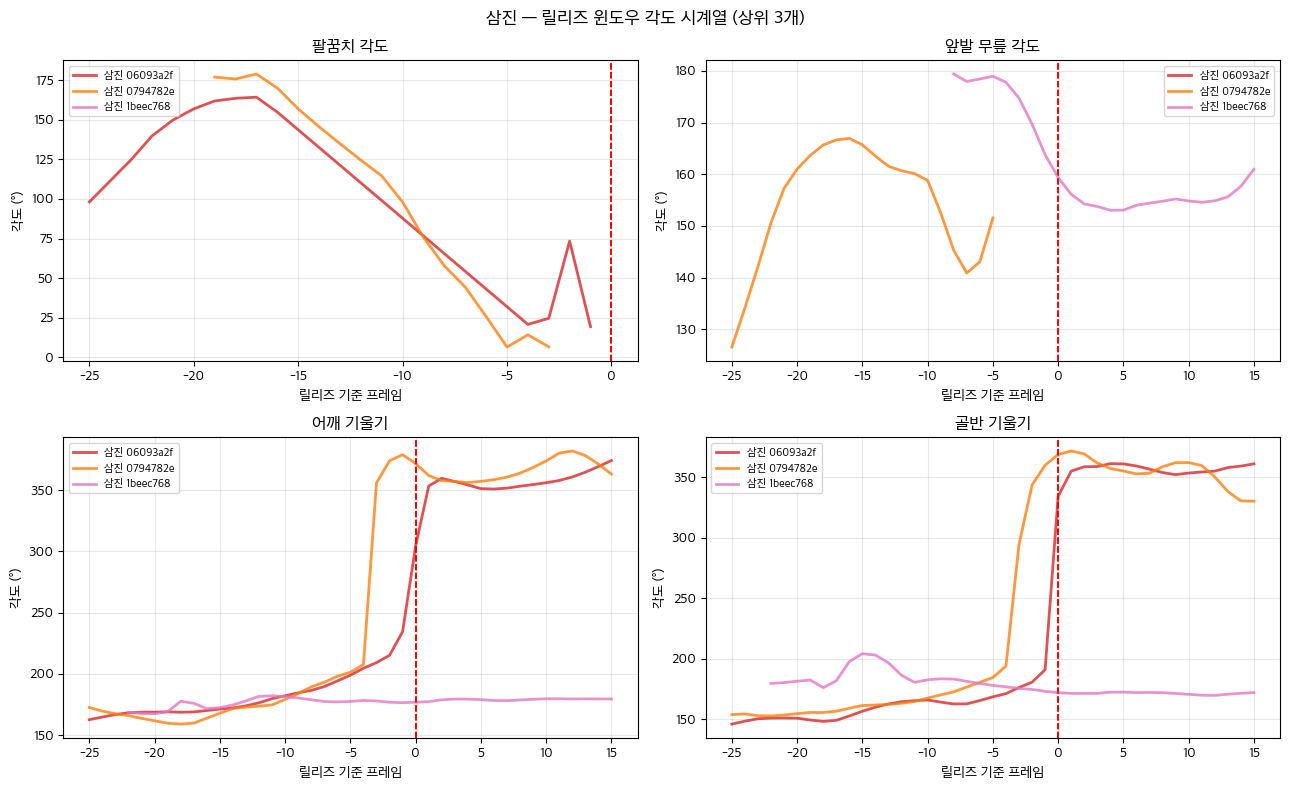

In [8]:
# 삼진 3개 오버레이
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('삼진 — 릴리즈 윈도우 각도 시계열 (상위 3개)', fontsize=13)

colors = ['#d62728', '#ff7f0e', '#e377c2']
sample_so = list(so_data.items())[:3]

for (pid, df), col in zip(sample_so, colors):
    plot_angle_series(pid, df, '삼진', col, axes.flatten())

for ax in axes.flatten():
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 📌 해석 가이드 — 릴리즈 윈도우 각도 시계열

각 그래프는 **릴리즈 순간(빨간 점선 = 0프레임)** 을 기준으로 전후 구간에서 관절 각도가 어떻게 변하는지를 보여줍니다.

| 그래프 | 의미 | 보는 포인트 |
|---|---|---|
| **팔꿈치 각도** | 투구 팔의 굽힘 정도 (180° = 완전히 펴진 상태) | 릴리즈 직전 얼마나 구부러져 있는지 |
| **앞발 무릎 각도** | 착지 다리의 굽힘 정도 | 릴리즈 시 다리가 얼마나 버텨주는지 |
| **어깨 기울기** | 어깨 라인의 회전 각도 | 릴리즈 전 어깨가 열리는 타이밍 |
| **골반 기울기** | 골반 라인의 회전 각도 | 어깨보다 먼저 돌아야 정상 (선행 회전) |

여러 투구가 겹쳐 그려지기 때문에 **선이 촘촘할수록 일관된 동작**, 흩어질수록 투구마다 편차가 크다는 의미입니다.

## 3. 릴리즈 순간 스켈레톤 시각화
릴리즈 ±2프레임 포즈가 실제로 맞는지 육안 확인

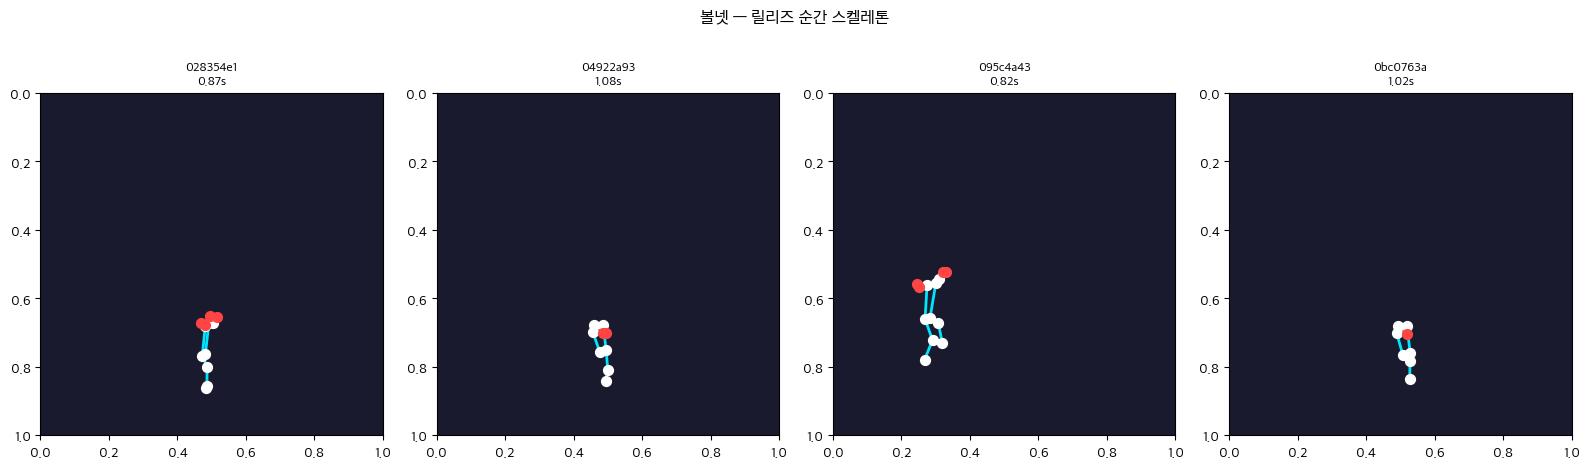

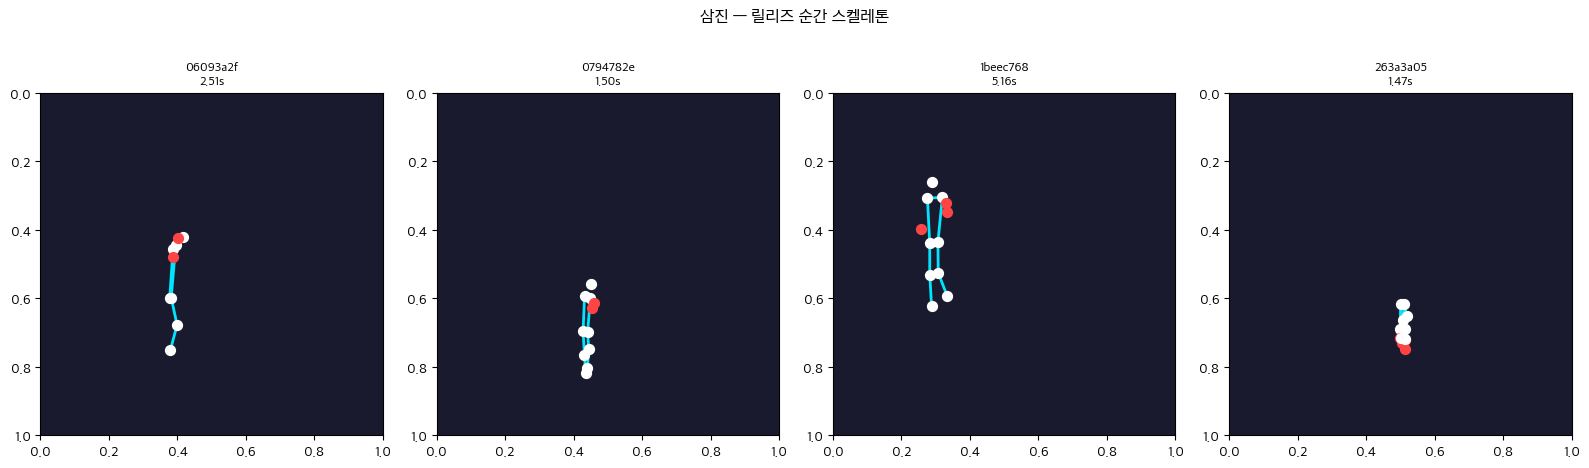

In [9]:
CONNECTIONS = [
    ('left_shoulder','right_shoulder'),
    ('left_shoulder','left_elbow'),   ('left_elbow','left_wrist'),
    ('right_shoulder','right_elbow'), ('right_elbow','right_wrist'),
    ('left_shoulder','left_hip'),     ('right_shoulder','right_hip'),
    ('left_hip','right_hip'),
    ('left_hip','left_knee'),         ('left_knee','left_ankle'),
    ('right_hip','right_knee'),       ('right_knee','right_ankle'),
]
JOINTS = ['nose','left_shoulder','right_shoulder','left_elbow','right_elbow',
          'left_wrist','right_wrist','left_hip','right_hip',
          'left_knee','right_knee','left_ankle','right_ankle']

def plot_skeleton_grid(data_dict, label, color, n_show=4):
    items = list(data_dict.items())[:n_show]
    fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 5))
    fig.suptitle(f'{label} — 릴리즈 순간 스켈레톤', fontsize=12)

    for ax, (pid, df) in zip(axes, items):
        rel_frame, rel_time = detect_release(df, throw_hand=THROW_HAND, method='velocity')
        if rel_frame is None:
            ax.set_title(f'{pid[:8]}\n감지 실패'); continue

        row = df[df['frame'] == rel_frame]
        if row.empty:
            row = df[df['detected'].fillna(False)].iloc[-1:]
        row = row.iloc[0]

        pts = {}
        for j in JOINTS:
            x, y = row.get(f'{j}_x'), row.get(f'{j}_y')
            if pd.notna(x) and pd.notna(y):
                pts[j] = (x, y)

        ax.set_facecolor('#1a1a2e')
        ax.set_xlim(0,1); ax.set_ylim(1,0)
        ax.set_aspect('equal')
        ax.set_title(f'{pid[:8]}\n{rel_time:.2f}s', fontsize=9)

        for a, b in CONNECTIONS:
            if a in pts and b in pts:
                ax.plot([pts[a][0],pts[b][0]], [pts[a][1],pts[b][1]],
                        color='#00e5ff', lw=2)
        for j, (x,y) in pts.items():
            c = '#ff4444' if 'wrist' in j or 'elbow' in j else '#ffffff'
            ax.scatter(x, y, color=c, s=50, zorder=5)

    plt.tight_layout()
    plt.show()

plot_skeleton_grid(walk_data, '볼넷', 'steelblue')
plot_skeleton_grid(so_data,   '삼진', 'tomato')

## 4. 볼넷 vs 삼진 지표 비교

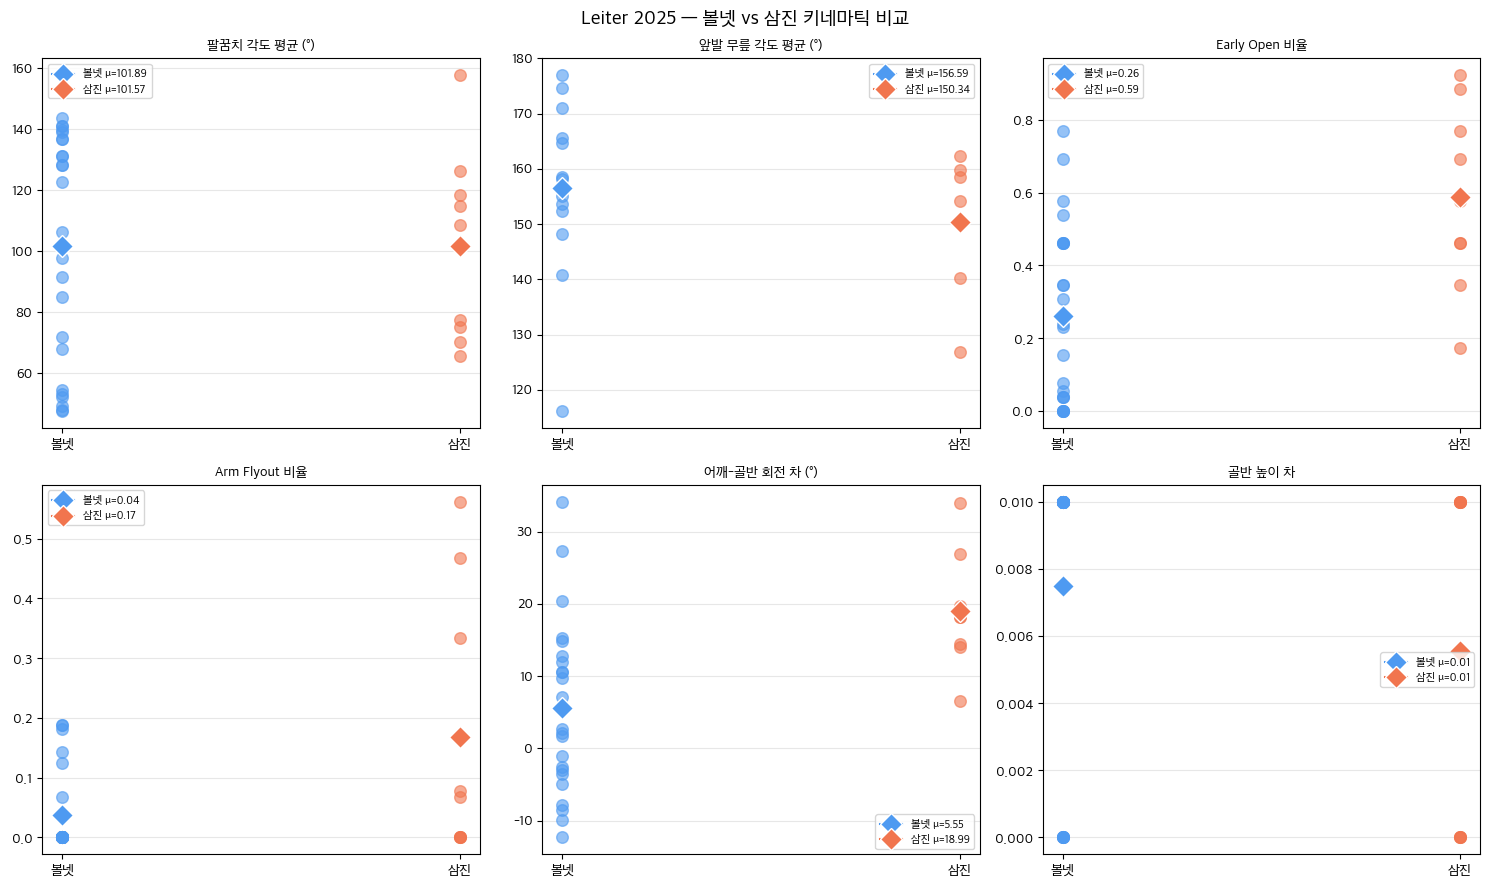

In [10]:
combined = pd.concat([walk_summary, so_summary], ignore_index=True)

metrics = [
    ('elbow_angle_mean',     '팔꿈치 각도 평균 (°)'),
    ('knee_angle_mean',      '앞발 무릎 각도 평균 (°)'),
    ('early_open_rate',      'Early Open 비율'),
    ('arm_flyout_rate',      'Arm Flyout 비율'),
    ('sh_hp_diff_mean',      '어깨-골반 회전 차 (°)'),
    ('hip_height_diff_mean', '골반 높이 차'),
]
metrics = [(m,t) for m,t in metrics if m in combined.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Leiter 2025 — 볼넷 vs 삼진 키네마틱 비교', fontsize=14)
colors = {'볼넷': '#4e9af1', '삼진': '#f1754e'}

for ax, (metric, title) in zip(axes.flatten(), metrics):
    for lbl, grp in combined.groupby('label'):
        vals = grp[metric].dropna()
        ax.scatter([lbl]*len(vals), vals,
                   color=colors[lbl], alpha=0.6, s=70, zorder=3)
        ax.plot([lbl], [vals.mean()], marker='D', color=colors[lbl],
                markersize=11, markeredgecolor='white', zorder=5,
                label=f'{lbl} μ={vals.mean():.2f}')

    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 해석 가이드 — 볼넷 vs 삼진 키네마틱 비교

각 지표에서 **점(개별 투구)** 과 **다이아몬드(평균)** 를 볼넷(파랑) / 삼진(주황)으로 비교합니다.

| 지표 | 볼넷 평균 | 삼진 평균 | 해석 |
|---|---|---|---|
| **팔꿈치 각도** | ~102° | ~102° | 두 그룹 차이 없음 — 팔 액션 자체는 유사 |
| **앞발 무릎 각도** | ~157° | ~150° | 큰 차이 없음 |
| **Early Open 비율** | **26%** | **59%** | ⚠️ 삼진 투구에서 몸통이 더 일찍 열림 |
| **Arm Flyout 비율** | **4%** | **17%** | ⚠️ 삼진 시 팔이 릴리즈 후 바깥으로 더 많이 빠짐 |
| **어깨-골반 회전 차 (X-factor)** | **6°** | **19°** | ✅ 삼진 투구에서 어깨-골반 분리각이 더 큼 |

> **Early Open**: 릴리즈 전에 어깨가 이미 타자 쪽을 향한 상태. 일반적으로 제구 불안정의 원인으로 알려져 있지만, 이 데이터에서는 오히려 삼진 투구에서 더 높게 나타났다. Leiter의 경우 파워 피칭 메커니즘과 연관될 가능성이 있다.

> **X-factor (어깨-골반 차)**: 골반이 먼저 열리고 어깨가 코일처럼 감긴 상태의 분리각. **값이 클수록 몸통 회전의 탄성에너지가 크고 더 폭발적인 투구가 가능**하다고 본다. 삼진 투구에서 더 높게 나타난 것은 파워 피칭의 특징과 일치한다.

## 5. 요약 통계

In [11]:
stat_cols = ['elbow_angle_mean','knee_angle_mean','early_open_rate',
             'arm_flyout_rate','sh_hp_diff_mean']
stat_cols = [c for c in stat_cols if c in combined.columns]

summary_stats = combined.groupby('label')[stat_cols].agg(['mean','std','count'])
summary_stats.round(3)

elbow_angle_mean               knee_angle_mean                \
                  mean     std count            mean     std count   
label                                                                
볼넷             101.892  37.211    24         156.593  14.838    15   
삼진             101.567  31.313     9         150.344  12.721     7   

      early_open_rate              arm_flyout_rate               \
                 mean    std count            mean    std count   
label                                                             
볼넷              0.262  0.245    24           0.037  0.070    24   
삼진              0.588  0.251     9           0.167  0.225     9   

      sh_hp_diff_mean                
                 mean     std count  
label                                
볼넷              5.554  11.808    24  
삼진             18.987   7.799     9

In [12]:
# 개별 pitch 데이터 확인
print('=== 볼넷 ===')
display(walk_summary[['play_id','game_date','release_speed',
                        'elbow_angle_mean','knee_angle_mean',
                        'early_open_rate','arm_flyout_rate']].round(2))
print('\n=== 삼진 ===')
display(so_summary[['play_id','game_date','release_speed',
                     'elbow_angle_mean','knee_angle_mean',
                     'early_open_rate','arm_flyout_rate']].round(2))

=== 볼넷 ===


,play_id,game_date,release_speed,elbow_angle_mean,knee_angle_mean,early_open_rate,arm_flyout_rate
0,028354e1-5cfc-3b08-a40a-38ca8efa32e1,2025-09-09,96.8,128.24,153.61,0.46,0.00
1,04922a93-2197-3389-86de-fa070dbe45aa,2025-08-06,97.4,52.17,NaN,0.00,0.00
2,095c4a43-d2bf-3b3d-82dd-18e420d2b80e,2025-08-18,96.3,136.93,156.23,0.31,0.19
3,0bc0763a-0129-39dd-9e25-20891288b7d6,NaN,NaN,49.14,NaN,0.04,0.00
4,43e5539a-773f-33e7-855f-9d4ce65cc5a8,2025-05-08,97.6,131.17,116.15,0.69,0.00
5,4e01ae11-69d9-3da5-8701-a4cfd58bc7ed,NaN,NaN,85.10,156.75,0.06,0.00
6,526d5742-8823-3ad7-ba56-6bf8c7637a6a,2025-05-08,96.2,139.09,NaN,0.24,0.18
7,5ea8a99a-9475-3781-984a-983d3b0e56bd,2025-05-30,99.6,54.36,NaN,0.00,0.00
8,6f5ca0ef-4b16-3824-a446-f2e6041895e1,NaN,NaN,47.56,152.32,0.00,0.00
9,6f80c54f-4c02-32ba-aad1-98f8ea07faaf,NaN,NaN,53.31,165.53,0.04,0.00



=== 삼진 ===


,play_id,game_date,release_speed,elbow_angle_mean,knee_angle_mean,early_open_rate,arm_flyout_rate
0,0794782e-c5db-3bdd-8774-4b91ac23bfe0,2025-08-02,99.3,77.32,154.20,0.35,0.00
2,4a8f5c09-74c6-3c40-bd56-69d312d60597,2025-04-25,99.4,114.92,159.81,0.46,0.47
3,6089bd57-f1a5-3528-89f9-4dbe8336e773,2025-08-02,99.8,157.80,126.83,0.58,0.56
4,63d3cd34-2157-35dc-9a2f-771903ebc364,2025-07-11,99.4,65.67,NaN,0.92,0.00
5,67a581c7-f10e-3d26-b5a6-276a43bbf8fe,2025-09-04,99.8,75.08,NaN,0.17,0.08
6,7aa1b406-65d6-3bc1-93ad-6e881aba518d,2025-08-07,99.7,126.28,140.30,0.77,0.33
7,855d0a65-6268-37be-a72e-1baca9f6a598,2025-05-23,99.4,118.35,150.31,0.88,0.00
8,9688a26a-57ca-3869-b40e-fe4d7dc20929,2025-07-06,99.4,108.50,158.59,0.69,0.07
10,d3710e3f-5b22-3b74-9b2e-abb1b1640619,2025-06-13,99.5,70.18,162.37,0.46,0.00


## 6. 키네마틱 시퀀스 비교
골반 → 몸통 → 팔꿈치 → 손목 순서로 속도 피크가 전달되는지 (Proximal-to-Distal 원칙)

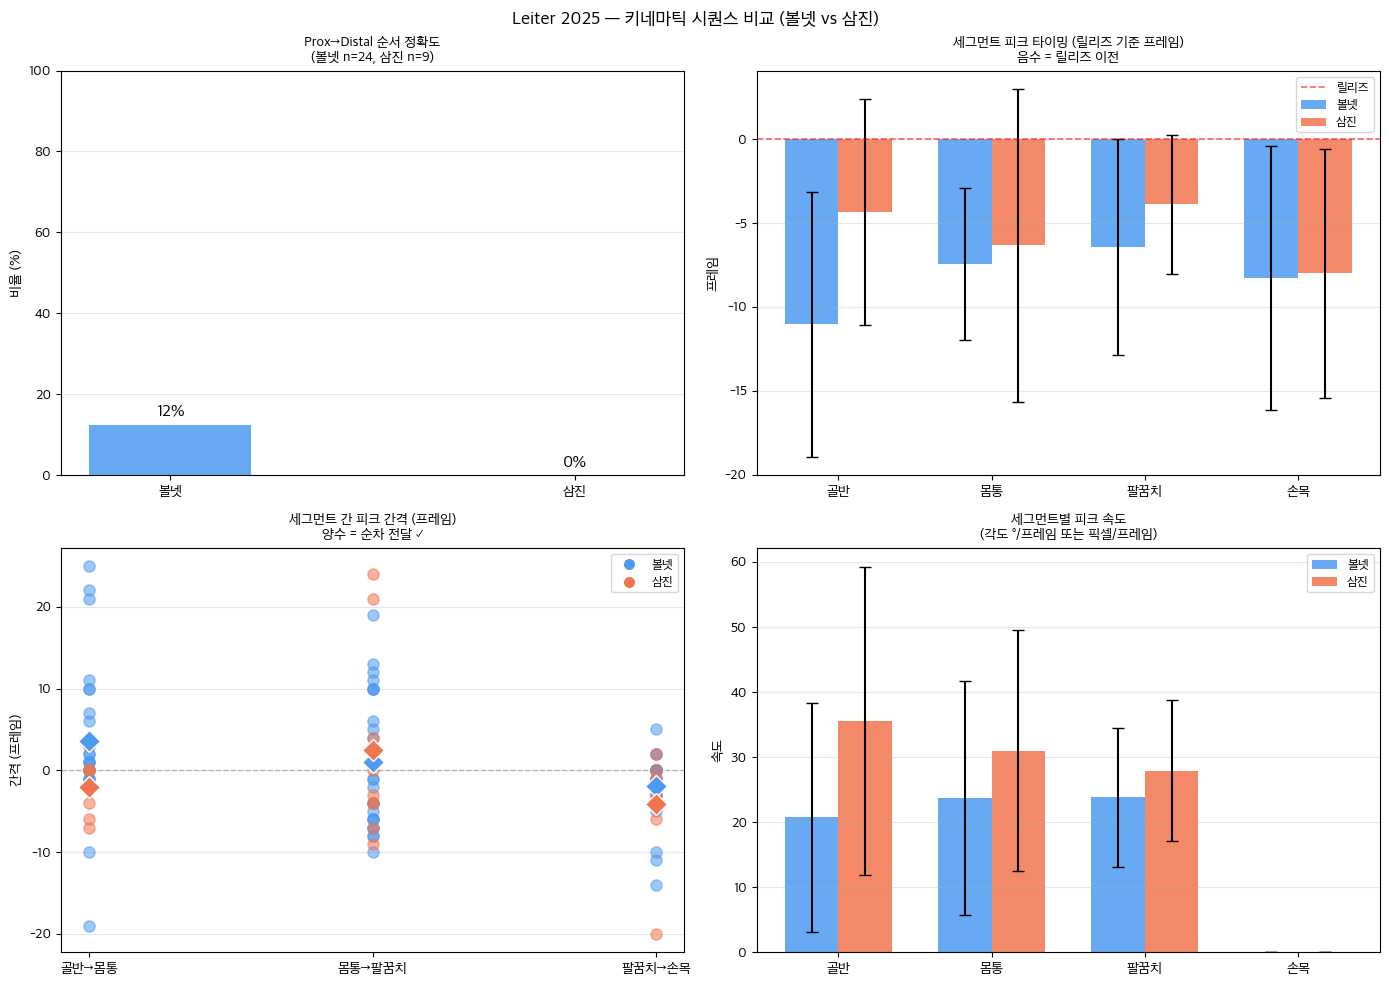

In [13]:
# ── 6-1. 시퀀스 지표 비교 ──────────────────────────────────────
seq_cols_check = [
    'seq_hip_offset','seq_trunk_offset','seq_elbow_offset','seq_wrist_offset',
    'seq_hip_to_trunk','seq_trunk_to_elbow','seq_elbow_to_wrist',
    'seq_correct',
    'seq_hip_peak_vel','seq_trunk_peak_vel','seq_elbow_peak_vel','seq_wrist_peak_vel',
]
seq_cols_check = [c for c in seq_cols_check if c in combined.columns]
combined_seq   = combined[['label'] + seq_cols_check].copy()

colors_seq = {'볼넷': '#4e9af1', '삼진': '#f1754e'}
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Leiter 2025 — 키네마틱 시퀀스 비교 (볼넷 vs 삼진)', fontsize=13)

# ① Proximal→Distal 정확도 비율
ax = axes[0, 0]
if 'seq_correct' in combined_seq.columns:
    rate = combined_seq.groupby('label')['seq_correct'].mean() * 100
    bars = ax.bar(rate.index, rate.values,
                  color=[colors_seq[l] for l in rate.index],
                  width=0.4, alpha=0.85)
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    n_walk = combined_seq[combined_seq['label']=='볼넷']['seq_correct'].count()
    n_so   = combined_seq[combined_seq['label']=='삼진']['seq_correct'].count()
    ax.set_title(f'Prox→Distal 순서 정확도\n(볼넷 n={n_walk}, 삼진 n={n_so})', fontsize=10)
    ax.set_ylabel('비율 (%)')
    ax.set_ylim(0, 100)
    ax.grid(True, axis='y', alpha=0.3)

# ② 릴리즈 기준 피크 타이밍 오프셋 (골반/몸통/팔꿈치/손목)
ax = axes[0, 1]
off_cols = [c for c in ['seq_hip_offset','seq_trunk_offset','seq_elbow_offset','seq_wrist_offset']
            if c in combined_seq.columns]
off_labels = ['골반','몸통','팔꿈치','손목'][:len(off_cols)]
x = np.arange(len(off_cols))

for i, lbl in enumerate(['볼넷','삼진']):
    grp   = combined_seq[combined_seq['label'] == lbl]
    means = [grp[c].dropna().mean() for c in off_cols]
    stds  = [grp[c].dropna().std()  for c in off_cols]
    ax.bar(x + (i - 0.5) * width, means, width,
           yerr=stds, label=lbl, color=colors_seq[lbl], alpha=0.85, capsize=4)

ax.axhline(0, color='red', lw=1.2, linestyle='--', alpha=0.6, label='릴리즈')
ax.set_title('세그먼트 피크 타이밍 (릴리즈 기준 프레임)\n음수 = 릴리즈 이전', fontsize=10)
ax.set_ylabel('프레임')
ax.set_xticks(x)
ax.set_xticklabels(off_labels)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# ③ 세그먼트 간 타이밍 간격 (양수 = 순차 전달)
ax = axes[1, 0]
gap_cols   = [c for c in ['seq_hip_to_trunk','seq_trunk_to_elbow','seq_elbow_to_wrist']
              if c in combined_seq.columns]
gap_labels = ['골반→몸통','몸통→팔꿈치','팔꿈치→손목'][:len(gap_cols)]

for lbl, grp in combined_seq.groupby('label'):
    for j, (col, glabel) in enumerate(zip(gap_cols, gap_labels)):
        vals = grp[col].dropna()
        ax.scatter([glabel]*len(vals), vals,
                   color=colors_seq[lbl], alpha=0.55, s=65, zorder=3,
                   label=lbl if j == 0 else '_nolegend_')
        if len(vals):
            ax.plot([glabel], [vals.mean()], marker='D',
                    color=colors_seq[lbl], markersize=11,
                    markeredgecolor='white', zorder=5)

ax.axhline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
ax.set_title('세그먼트 간 피크 간격 (프레임)\n양수 = 순차 전달 ✓', fontsize=10)
ax.set_ylabel('간격 (프레임)')
handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=colors_seq[l], markersize=9, label=l)
           for l in ['볼넷','삼진']]
ax.legend(handles=handles, fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# ④ 세그먼트별 피크 속도
ax = axes[1, 1]
vel_cols   = [c for c in ['seq_hip_peak_vel','seq_trunk_peak_vel',
                           'seq_elbow_peak_vel','seq_wrist_peak_vel']
              if c in combined_seq.columns]
vel_labels = ['골반','몸통','팔꿈치','손목'][:len(vel_cols)]
x = np.arange(len(vel_cols))

for i, lbl in enumerate(['볼넷','삼진']):
    grp   = combined_seq[combined_seq['label'] == lbl]
    means = [grp[c].dropna().mean() for c in vel_cols]
    stds  = [grp[c].dropna().std()  for c in vel_cols]
    ax.bar(x + (i - 0.5) * width, means, width,
           yerr=stds, label=lbl, color=colors_seq[lbl], alpha=0.85, capsize=4)

ax.set_title('세그먼트별 피크 속도\n(각도 °/프레임 또는 픽셀/프레임)', fontsize=10)
ax.set_ylabel('속도')
ax.set_xticks(x)
ax.set_xticklabels(vel_labels)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 해석 가이드 — 키네마틱 시퀀스 비교

#### 이상적인 투구의 에너지 전달 원리

투구 동작은 **근위부(몸통)에서 원위부(손 끝)로 에너지를 순차 전달**하는 채찍(whip) 구조입니다.

```
골반 가속 → [골반 피크] → 골반 감속 → 몸통 가속 → [몸통 피크] → 몸통 감속
→ 팔꿈치 가속 → [팔꿈치 피크] → 팔꿈치 감속 → 손목 가속 → [손목 피크 ≈ 릴리즈]
```

- 앞 세그먼트가 **감속하면서** 다음 세그먼트로 에너지를 넘겨주는 것이 핵심
- **손목이 릴리즈 순간에 최대 속도**에 도달하는 것이 이상적
- 팔꿈치는 릴리즈 직전에 피크 → 감속하며 손목으로 전달

#### 각 서브플롯 읽는 법

| 플롯 | 보는 포인트 |
|---|---|
| **① 순서 정확도** | 골반→몸통→팔꿈치→손목 순서가 지켜진 비율. 낮은 이유: 2D 센터필드 카메라는 투수 회전 동작을 정면에서 포착하기 어려움 |
| **② 피크 타이밍** | 각 세그먼트가 릴리즈(0) 몇 프레임 전에 피크에 도달하는지. 골반이 가장 음수(릴리즈로부터 멀리), 손목이 0에 가장 가까워야 함 |
| **③ 세그먼트 간격** | 앞→뒤 피크 간 시간 차. **양수 = 순차 전달(정상)**, 음수 = 역순 |
| **④ 피크 속도** | 각 세그먼트의 최대 속도. 원위부로 갈수록 속도가 누적·증폭되는 것이 이상적 |

볼넷 kinseq: 24개 | 삼진 kinseq: 9개


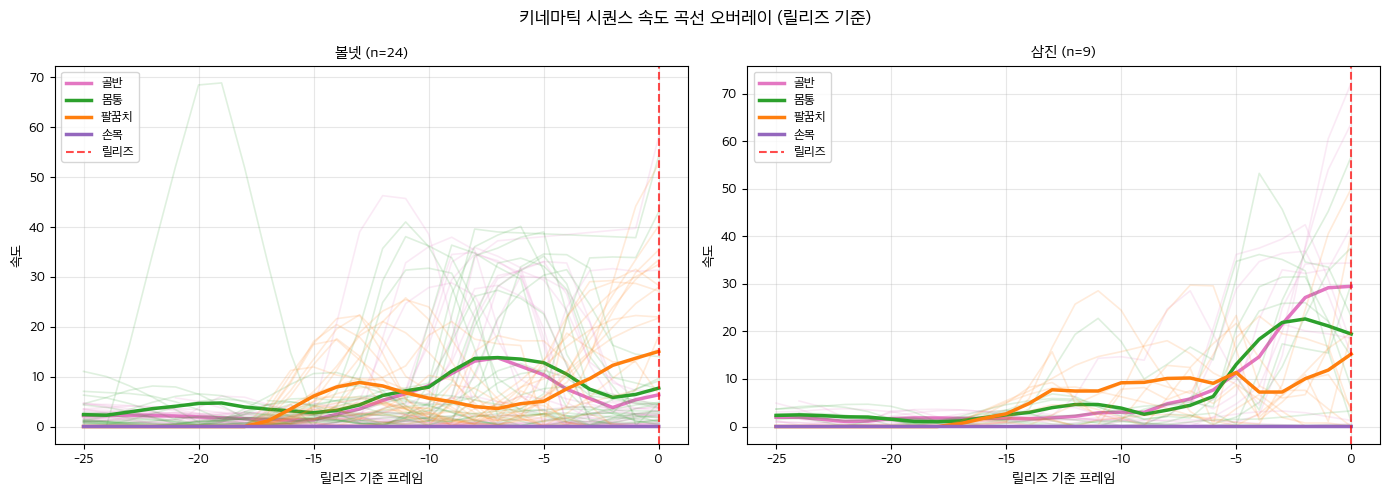

In [15]:
# ── 6-2. 속도 곡선 오버레이 (볼넷 / 삼진 서브플롯, 4개 세그먼트 한 플롯에) ──────
def load_kinseq_csvs(directory, summary_df):
    valid_ids = set(summary_df['play_id'].values)
    data = {}
    for f in sorted(Path(directory).glob('*_kinseq.csv')):
        pid = f.stem.replace('_kinseq', '')
        if pid in valid_ids:
            df = pd.read_csv(f)
            df['frame_offset'] = df['frame'] - df['frame'].max()
            data[pid] = df
    return data

walk_kinseq = load_kinseq_csvs(WALK_DIR, walk_summary)
so_kinseq   = load_kinseq_csvs(SO_DIR,   so_summary)
print(f'볼넷 kinseq: {len(walk_kinseq)}개 | 삼진 kinseq: {len(so_kinseq)}개')

segments = [
    ('hip_vel',   '골반',   '#e377c2'),
    ('trunk_vel', '몸통',   '#2ca02c'),
    ('elbow_vel', '팔꿈치', '#ff7f0e'),
    ('wrist_vel', '손목',   '#9467bd'),
]

fig, (ax_walk, ax_so) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('키네마틱 시퀀스 속도 곡선 오버레이 (릴리즈 기준)', fontsize=13)

for ax, lbl, kinseq_dict in [
    (ax_walk, '볼넷', walk_kinseq),
    (ax_so,   '삼진', so_kinseq),
]:
    for col, seg_lbl, seg_color in segments:
        # 개별 투구 (반투명)
        for df in kinseq_dict.values():
            if col in df.columns:
                ax.plot(df['frame_offset'], df[col],
                        color=seg_color, alpha=0.15, lw=1.2)
        # 평균 곡선 (굵게)
        frames_list = [df[['frame_offset', col]] for df in kinseq_dict.values()
                       if col in df.columns]
        if frames_list:
            mean_curve = pd.concat(frames_list).groupby('frame_offset')[col].mean()
            ax.plot(mean_curve.index, mean_curve.values,
                    color=seg_color, lw=2.5, label=seg_lbl)

    ax.axvline(0, color='red', lw=1.5, linestyle='--', alpha=0.7, label='릴리즈')
    ax.set_title(f'{lbl} (n={len(kinseq_dict)})', fontsize=11)
    ax.set_xlabel('릴리즈 기준 프레임')
    ax.set_ylabel('속도')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 해석 가이드 — 속도 곡선 오버레이

왼쪽(볼넷) / 오른쪽(삼진) 각각의 플롯에서 **4개 세그먼트의 속도 변화**를 릴리즈(x=0) 기준으로 정렬해 보여줍니다.

| 색상 | 세그먼트 | 측정 방식 |
|---|---|---|
| 분홍 | 골반 | 골반 기울기 각속도 (°/프레임) |
| 초록 | 몸통 | 어깨 기울기 각속도 (°/프레임) |
| 주황 | 팔꿈치 | 팔꿈치 각도 변화속도 (°/프레임) |
| 보라 | 손목 | 손목 좌표 이동 선속도 (px/프레임) |

**연한 선** = 개별 투구 / **굵은 선** = 평균 / **빨간 점선** = 릴리즈

#### 이상적인 패턴
피크 순서가 **분홍(골반) → 초록(몸통) → 주황(팔꿈치) → 보라(손목)** 로 왼쪽에서 오른쪽으로 이동하고, **손목 피크(보라)가 릴리즈(x=0) 근처**에 위치해야 합니다. 팔꿈치(주황)는 릴리즈 직전에 피크를 찍고 감속하면서 손목으로 에너지를 전달합니다.

 ## 포즈 추출

 - pose_extractor_yolo.py — YOLO 트래킹 + MediaPipe 포즈 추출 (핵심)
 - run_batch_pose.py — 배치 실행

## 영상 전처리

 - trim_videos.py — 투구 장면 트리밍

## 데이터 다운로드

 - download_walks.py — 볼넷 영상
 - download_strikeouts.py — 삼진 영상


## 포즈 데이터 전처리

 - pose_preprocessor.py — 필터링, 인터폴레이션, 스무딩


## 분석

 - release_detector.py — 릴리즈 포인트 감지
 - run_analysis.py — 각도/키네마틱 계산


## 시각화

 - leiter_kinematics_analysis.ipynb — 주피터 노트북
 - visualize_analysis.py — PNG 저장용 스크립트